# Quick start: isaac-net in three minutes

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ZzZTripleZzZ/isaac-net/blob/main/docs/tutorials/00_quickstart_colab.ipynb)

This notebook installs `isaac-net` from PyPI, simulates the 5G uplink of 64 environments with 8 robots each, and plots the delay distribution and the age of information (AoI). It then shows how a preset differs from the default configuration and how strict mode catches a setting that a level would ignore.

It runs on a free Colab runtime in under three minutes. A CPU runtime is enough. With a GPU runtime (*Runtime > Change runtime type > T4 GPU*) the engine uses the `graph` backend, which replays each control step as one CUDA graph and is bitwise equal to the `reference` backend used on a CPU.

The numbers you get depend on the hardware and on the random draws. They show how to read each output and are not measurements of the engine.

## Install

Colab already has PyTorch, so this installs only the package (pure Python, under 1 MB). The cell skips the install when `isaac_net` is already importable, for example in a local clone.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("isaac_net") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "isaac-net>=0.2.0"])

import isaac_net
import torch

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
backend = "graph" if dev.type == "cuda" else "reference"
print("isaac_net", isaac_net.__version__, "| torch", torch.__version__, "| device", dev, "| backend", backend)

isaac_net 0.2.1.dev0 | torch 2.9.1 | device cpu | backend reference


## Build an engine

`make_engine(level, E, R, device, config, backend)` builds every fidelity level behind one API. Level `L2` is the configurable NR engine: a 3GPP frame structure, proportional-fair scheduling, link adaptation, HARQ retransmissions and RLC, stepped slot by slot for all environments at once. `NRConfig()` is its default configuration, and `seed` keys every random draw by (seed, env id, episode).

In [2]:
from isaac_net import NRConfig, Requests, make_engine

E, R = 64, 8                                      # 64 environments x 8 robots = 512 robots
cfg = NRConfig()
net = make_engine("L2", E, R, dev, cfg, backend=backend, seed=0)
print(cfg.summary())

mu=1 (30 kHz), 20 MHz -> 51 PRB, RBG 4 -> 13 subbands [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3], TDD DDDSU S=(10, 2, 2), 200 slots/step (40 UL, 160 DL data slots), HARQ 16x4tx rlc_am, MCS table 1, eesm, OLLA on, PF subband


## Step the network for 50 control steps

Each control step has two calls. `submit(None, Requests(send))` enqueues at most one message per robot, where `send[e, r]` is 0 for nothing or the message class: 1 for a 4 kB message and 2 for a 30 kB frame. `step(None, poses)` then advances every environment by one control step (100 ms of simulated time), with the robot positions in metres going through the engine's radio model. `None` means each environment's own clock.

The AoI of a robot is how old the freshest delivered information about it is: `t + 1 - last`, where `last` is the capture step of the newest delivered message.

In [3]:
g = torch.Generator(device=dev).manual_seed(0)
pos = torch.rand(E, R, 2, device=dev, generator=g) * 100.0      # robots within 100 m, gNB at the origin
last = torch.zeros(E, R, dtype=torch.long, device=dev)          # the state at reset counts as known
delays_ms, aoi_mean_ms, aoi_p95_ms = [], [], []

for t in range(50):
    want = torch.rand(E, R, device=dev, generator=g) < 0.3       # 30% of robots send each step ...
    big = torch.rand(E, R, device=dev, generator=g) < 0.3        # ... a third of them a 30 kB frame
    send = want.long() * torch.where(big, 2, 1)
    net.submit(None, Requests(send))
    out = net.step(None, pos)
    delays_ms.append((out["delay"][out["delivered"]] * cfg.control_step_ms).cpu())
    last = torch.maximum(last, out["newest"])
    aoi = (out["t"][:, None] + 1 - last).float() * cfg.control_step_ms
    aoi_mean_ms.append(aoi.mean().item())
    aoi_p95_ms.append(aoi.quantile(0.95).item())
    pos = (pos + 1.5 * torch.randn(E, R, 2, device=dev, generator=g)).clamp(0.0, 100.0)   # robots move

delays_ms = torch.cat(delays_ms)
print("step dict keys:", sorted(out))
print(f"delivered {len(delays_ms)} messages, median delay {delays_ms.median():.1f} ms, "
      f"p95 {delays_ms.quantile(0.95):.1f} ms, still queued {int(out['queue_len'].sum())}")

step dict keys: ['cap', 'cls', 'delay', 'delivered', 'det_env', 'dropped', 'newest', 'queue_bytes', 'queue_len', 'serving_cell', 'sinr_db', 't', 'timed_out']
delivered 6765 messages, median delay 52.5 ms, p95 1157.5 ms, still queued 575


The per-message outputs (`delivered`, `timed_out`, `dropped`, `delay`, `cap`, `cls`) have shape `[E, R, F]`: one entry per slot of each robot's 16-message buffer, as the queue stood before the step. The per-robot outputs (`newest`, `queue_len`, `queue_bytes`, `sinr_db`, `serving_cell`) have shape `[E, R]`, and `t` is each environment's clock. `delay` is in control steps, so multiply by `cfg.control_step_ms` for milliseconds.

## Plot the delay CDF and the AoI over time

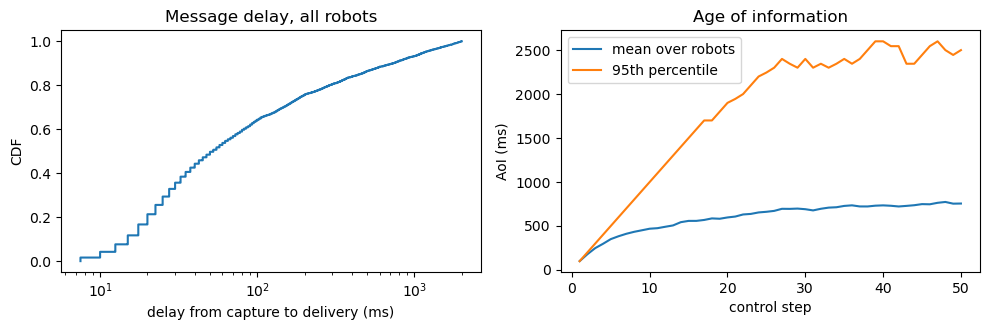

In [4]:
import matplotlib.pyplot as plt

fig, (a, b) = plt.subplots(1, 2, figsize=(10, 3.4))
d = delays_ms.sort().values
a.step(d, torch.arange(1, len(d) + 1) / len(d), where="post")
a.set_xscale("log")
a.set_xlabel("delay from capture to delivery (ms)")
a.set_ylabel("CDF")
a.set_title("Message delay, all robots")
b.plot(range(1, 51), aoi_mean_ms, label="mean over robots")
b.plot(range(1, 51), aoi_p95_ms, label="95th percentile")
b.set_xlabel("control step")
b.set_ylabel("AoI (ms)")
b.set_title("Age of information")
b.legend()
fig.tight_layout()
plt.show()

Delays are multiples of the uplink slot spacing, which gives the CDF its steps at the low end. Small messages from robots near the gNB arrive within the control step, while 30 kB frames from robots far from it wait for several grants and retransmissions, and a message still queued after 2 s (20 control steps) is dropped as timed out. The mean AoI levels off once deliveries keep pace with the traffic. The 95th percentile levels off much higher, because a few robots far from the gNB, with a low SINR and a long queue, get a message through only every few seconds. A policy trained against `L2` sees exactly this spread between robots.

## The default configuration is not the validated one

`NRConfig()` is the engine's default, and it is **not** validated: replaying the ns-3 5G-LENA sweep with it puts the median delay 29–76% low. `lena_validation_v2()` is the configuration that matches 5G-LENA (median delay error a few percent across load). Presets are plain functions that return an `NRConfig`, so you can list exactly which fields differ.

In [5]:
import dataclasses

from isaac_net.core import lena_validation_v2

v2 = lena_validation_v2()
for f in dataclasses.fields(NRConfig):
    a, b = getattr(cfg, f.name), getattr(v2, f.name)
    if a != b:
        print(f"{f.name:22s} NRConfig() = {a!r:14} lena_validation_v2() = {b!r}")

n_prb                  NRConfig() = None           lena_validation_v2() = 50
rbg_size               NRConfig() = None           lena_validation_v2() = 10
ul_data_symbols        NRConfig() = 12             lena_validation_v2() = 13
dmrs_re_per_prb        NRConfig() = 12             lena_validation_v2() = 0
harq_combining         NRConfig() = 'cc'           lena_validation_v2() = 'ir_lena'
harq_fail              NRConfig() = 'rlc_am'       lena_validation_v2() = 'drop'
discard                NRConfig() = 'purge'        lena_validation_v2() = 'pdcp_arrival'
bler_source            NRConfig() = 'pdsch'        lena_validation_v2() = 'lena'
tbs_mode               NRConfig() = '38214'        lena_validation_v2() = 'lena'
olla                   NRConfig() = True           lena_validation_v2() = False
pf_metric              NRConfig() = 'subband'      lena_validation_v2() = 'wideband'
pf_update              NRConfig() = 'slot'         lena_validation_v2() = 'rbg'
pf_avg_idle            NRConfig(

`bler_source="lena"` uses the 5G-LENA BLER tables, which are GPL-2.0 data and are never shipped. Generate them from your own 5G-LENA checkout with `python -m isaac_net.tools.extract_lena_tables <path>` before you build an engine from this preset. The [Cookbook](https://isaacnet.zifanzhang.com/docs/cookbook/) shows the scale variant that the fused `triton` kernel accepts.

## Strict mode catches ignored fields

Every level reads only some of the config fields. The prototype levels such as `L2-legacy` have a fixed radio and MAC, so a field such as `n_harq` does nothing there. `unused_fields(level)` lists the fields you set that the level ignores, and `strict=True` turns them into an error.

In [6]:
custom = NRConfig(n_harq=8, mcs_table=2)
print("L2-legacy ignores:", custom.unused_fields("L2-legacy"))
print("L2 ignores:", custom.unused_fields("L2"))
try:
    make_engine("L2-legacy", E, R, dev, custom, strict=True)
except ValueError as err:
    print("strict=True:", err)

L2-legacy ignores: ['mcs_table', 'n_harq']
L2 ignores: []
strict=True: level L2-legacy ignores these config fields: mcs_table, n_harq (see NRConfig.unused_fields and docs/configurability.md)


## Where to go next

- [Choosing a configuration](https://isaacnet.zifanzhang.com/docs/choosing/): which fidelity level, backend, preset and simulator to use.
- [Tutorials 01–05](https://isaacnet.zifanzhang.com/docs/tutorials/): partial resets, the fidelity levels side by side, `NRConfig` in depth, the Isaac Lab layer and validation against ns-3.
- [Cookbook](https://isaacnet.zifanzhang.com/docs/cookbook/): ten short recipes, from domain randomization to QoS classes and multi-GPU sharding.
- [Isaac Lab on Windows](https://isaacnet.zifanzhang.com/docs/isaac-lab/) and [on Linux](https://isaacnet.zifanzhang.com/docs/isaac-lab-linux/): put the network into a `DirectRLEnv`.
- [FAQ](https://isaacnet.zifanzhang.com/docs/faq/): why numbers differ from the README, what `triton` refuses, how to cite the project.